# 07 · Cutting the articles into chunks

Retrieval does not operate on whole articles. It operates on short passages, so that a question
can be matched against the specific piece of text that answers it. This notebook describes how
each article in the corpus is divided into such passages, which are termed chunks.

The division is performed by the code in `ocular/rag/chunk.py`. The chunks are produced and
cached as a by-product of building an index, by the script `scripts/build_index.py`, which writes
one cache file per strategy under `data/index/_chunks/`. The present notebook reads those caches
rather than recomputing them.

## Three ways to divide an article

How an article is divided is not self-evident, and different choices lead to different retrieval
quality, so three strategies were implemented and later compared as a formal experiment.

The **fixed** strategy packs consecutive sentences together up to a target length with a small
overlap, ignoring the article's own structure. The **section** strategy respects the sections of
the article, so that a chunk never crosses a heading and a section is subdivided only when it
grows beyond the size limit. The **semantic** strategy divides the text at the points where the
topic changes, which are detected from a fall in similarity between neighbouring sentences.

All three strategies operate over whole sentences, so no chunk ever ends in the middle of one.

## How the chunking is implemented

The three strategies live in `ocular/rag/chunk.py`, and all of them are reached through one entry
point, the function `chunk_document`. Before any strategy runs, the helper `_units` flattens an
article into a list of `(section, sentence)` units in reading order, using `_split_sentences` to
break each section into sentences. Every strategy therefore works on whole sentences, which is what
guarantees that no chunk ever ends in the middle of one. This section explains what each strategy
does behind the scenes rather than reproducing the code.

**Fixed.** The function `_fixed` walks the sentences in order and keeps adding them to the current
chunk until the next sentence would push it past a target of about two hundred words. It then closes
the chunk and starts the next one, carrying the last forty words of the previous chunk over as
overlap, so that a passage which falls on a boundary is still present in both neighbours. Section
headings are ignored, which is the reason this strategy produces the most chunks.

**Section.** The function `_section` groups the sentences by their section and fills a chunk only
within one section, so a chunk never crosses a heading. A section shorter than the size cap becomes a
single chunk, and only a section longer than about three hundred words is divided further. This is the
reason the section strategy produces fewer and larger chunks.

**Semantic.** The function `_semantic` embeds every sentence and measures the distance between each
sentence and the one that follows it, then starts a new chunk wherever that distance reaches a chosen
percentile of all the distances in the article, or wherever the running chunk would exceed the size
cap. The way that boundary is chosen is described in more detail in a later section.

Whichever strategy is used, `chunk_document` wraps each resulting piece in a `Chunk` that carries the
article identifier, the title, the DOI, the licence and the section heading alongside the text, so
that a retrieved passage can always be traced back to its source article and cited.

In [1]:
import json

import pandas as pd

from ocular.rag import index

cache_dir = index.INDEX_DIR / "_chunks"

rows = []
for strategy in ("fixed", "section", "semantic"):
    chunks = [json.loads(line) for line in (cache_dir / f"chunks_{strategy}.jsonl").open()]
    words = [len(c["text"].split()) for c in chunks]
    rows.append({
        "strategy": strategy,
        "chunks": len(chunks),
        "mean words": round(sum(words) / len(words)),
        "shortest": min(words),
        "longest": max(words),
    })
pd.DataFrame(rows)

,strategy,chunks,mean words,shortest,longest
0,fixed,15203,183,2,413
1,section,10763,182,1,302
2,semantic,12186,161,1,302


The three strategies produce different numbers of chunks from the same 508 articles. The fixed
strategy yields the most, because its target length is short and it does not stop at section
boundaries. The section strategy yields fewer and larger chunks, since a short section becomes a
single chunk. The distribution of chunk sizes makes the difference clearer.

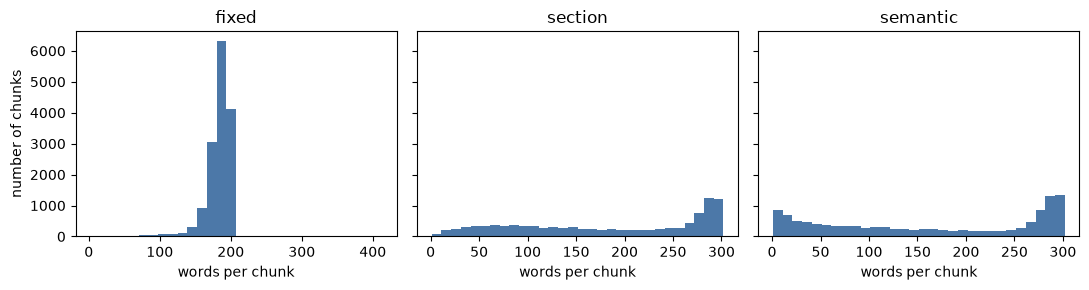

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for ax, strategy in zip(axes, ("fixed", "section", "semantic")):
    chunks = [json.loads(line) for line in (cache_dir / f"chunks_{strategy}.jsonl").open()]
    words = [len(c["text"].split()) for c in chunks]
    ax.hist(words, bins=30, color="#4C78A8")
    ax.set_title(strategy)
    ax.set_xlabel("words per chunk")
axes[0].set_ylabel("number of chunks")
plt.tight_layout()
plt.show()

## The same article divided three ways

To make the distinction concrete, the cell below takes a single article and reports how each
strategy divides it. The semantic strategy requires an embedding model to detect topic shifts,
and a small general model is used for this purpose, kept fixed so that the chunk boundaries do
not depend on the embedding model chosen later for retrieval.

In [3]:
from ocular.rag import chunk, corpus

doc = corpus.load_corpus()[0]
embed = index.load_embedder("sentence-transformers/all-MiniLM-L6-v2")

print(f"article: {doc.title[:70]}\n")
for strategy in ("fixed", "section", "semantic"):
    kwargs = {"embed_fn": embed} if strategy == "semantic" else {}
    chunks = chunk.chunk_document(doc, strategy=strategy, **kwargs)
    sizes = [len(c.text.split()) for c in chunks]
    print(f"{strategy:9} -> {len(chunks):2} chunks, sizes {min(sizes)}-{max(sizes)} words")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

article: Topographically Resolved Macular Pigment Optical Density Is Associated

fixed     -> 20 chunks, sizes 159-200 words
section   -> 16 chunks, sizes 51-297 words
semantic  -> 17 chunks, sizes 21-298 words


## How the semantic strategy finds a boundary

The semantic strategy embeds each sentence as a vector and measures how similar each sentence is
to the one that follows it. A pronounced fall in similarity indicates a change of subject, and the
article is cut at that point. The cut points are chosen with a percentile threshold rather than a
fixed value, so the strategy adapts to the internal variation of each article rather than applying
one universal cutoff.

## What was run

The chunk caches read above were produced while building the retrieval indexes. For a single
configuration the command is

    python scripts/build_index.py --chunk-strategy section --embed-model sentence-transformers/all-MiniLM-L6-v2

and the complete grid of nine indexes was built with a single driver,

    python scripts/build_all_indexes.py

which walks every strategy and embedding model, skips whatever has already been built, and writes
the chunk cache once per strategy. Caching the chunks separately matters because the boundaries
depend only on the strategy, so several embedding models reuse the same chunks without paying the
cost of dividing the corpus again, which is most significant for the semantic strategy whose
detection of boundaries embeds every sentence in the corpus.

Across the 508 articles these commands wrote 15,203 fixed chunks, 10,763 section chunks and 12,186
semantic chunks. These are the totals reported in the table near the top of the notebook, since the
cells above read the same cache files back rather than dividing the corpus again.

## Summary

- Each article is divided into short **chunks**, so that retrieval can match a question against the
  exact passage that answers it.
- Three strategies were implemented, **fixed**, **section** and **semantic**, which differ in
  whether they respect a target length, the structure of the article, or shifts in topic.
- The chunks are cached once per strategy and reused by every embedding model, which keeps the
  cost of the later experiments manageable.

The following notebook, `08`, describes how these chunks are embedded and searched.